# Step 4 — the ten-metric non-linearity figure (R1-MJ-2, R2-MJ-3/7b/8/12, R1-mn-8b)

The main text shows one non-linearity figure: predicted P(success) as a quadratic function of
log-pleiotropy, therapeutic areas (top) and gPS (bottom), model-with-GWAS versus its LOWESS
observed curve versus model-no-GWAS. Referees asked whether that shape survives once pleiotropy is
corrected for trait redundancy (`01_metrics_and_gate.ipynb`) and whether it holds on measurement
traits, not just diseases (R1-MJ-2). `02_drug_targets.ipynb` answered that with regression tables.
This notebook re-draws the same figure recipe for all nine counts, plus a tenth added on referee
follow-up — independent measurements after dropping any measurement trait that is itself genetically
correlated (|rg| > 0.7) with a disease trait in S — so the tables in `02_drug_targets.ipynb` have a
visual companion.

**Panels 1 and 2 (Therapeutic areas, Diseases/gPS) reproduce the main-text figure exactly** — same
formula (`outcome ~ geneticSupport + log(x+1) + log(x+1)^2`), same source table
(`df_for_enrichment_regression.csv`), same bootstrap recipe (B=200, seed=42, LOWESS frac=0.3). They
are not re-derived from the Step 3 pair table; they are the identical computation, included here only
so all nine sit in one figure.

Panels 3-10 run the identical recipe on the eight counts from Step 3, on `pairs` (the 37,377-row
table from `../or10-optimism-validation/01_build_pair_tables.ipynb`), with `support_all` as the
genetic-support indicator and `approved` as the outcome. Panel 10 is defined on far fewer genes
(only 26% of genes have any surviving disease-decorrelated measurement trait — 90.3% of measurement
traits in S correlate > 0.7 with some disease trait), so its curve is noisier than the others.

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import NullFormatter, ScalarFormatter
from scipy.interpolate import interp1d

sys.path.insert(0, ".")
sys.path.insert(0, "../or10-optimism-validation")
from or10_stats import or_rs, support_mask

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)

INTERMEDIATE = "../../../data/intermediate_files/"

## Data — two sources, one row set

`df_main` is the exact table the main-text figure is drawn from. `pairs` is the Step 3 table with
the four new metrics and the three reference overlap counts merged on, built the same way as in
`02_drug_targets.ipynb` (same merge, same `in_gps` zero-fill, same `support_all` definition) so the
seven new panels are on the identical 37,377 pairs and the identical genetic-support/approval
labels as the tables already reported there.

In [2]:
df_main = pd.read_csv(INTERMEDIATE + "df_for_enrichment_regression.csv")

pairs = pd.read_parquet(INTERMEDIATE + "ti_pairs_chembl_master-r1.parquet")
metrics = pd.read_csv(INTERMEDIATE + "eit_gene_metrics-r1.csv")

METRIC_COLUMNS = {
    "gps_measurement": "gps_measurement",
    "gps_independent_traits": "gps_independent_traits",
    "n_overlap": "n_overlap",
    "gps_independent_diseases": "gps_independent_diseases",
    "n_overlap_diseases": "n_overlap_diseases",
    "gps_independent_measurements": "gps_independent_measurements",
    "n_overlap_measurements": "n_overlap_measurements",
    "gps_independent_measurements_nodisease": "gps_independent_measurements_nodisease",
}

pairs = pairs.merge(
    metrics[
        [
            "geneId",
            "gps_measurement",
            "n_overlap",
            "gps_independent_traits",
            "n_overlap_diseases",
            "gps_independent_diseases",
            "n_overlap_measurements",
            "gps_independent_measurements",
            "gps_independent_measurements_nodisease",
        ]
    ],
    left_on="targetId",
    right_on="geneId",
    how="left",
)
pairs["support_all"] = support_mask(pairs).astype(int)
for name, col in METRIC_COLUMNS.items():
    pairs[name] = pairs[col].where(pairs["in_gps"], 0.0)
pairs = pairs.rename(columns={"approved": "outcome"})

print("df_main:", len(df_main), "pairs | pairs:", len(pairs), "pairs")
assert len(df_main) == len(pairs) == 37377

df_main: 37377 pairs | pairs: 37377 pairs


## The nine metrics

Same nine rows and same order as the referee-response table in `02_drug_targets.ipynb`; the first
two are the published metrics on `df_main`, the rest are the seven Step 3 counts on `pairs`.

| # | Label | Source | Column | Genetic-support column |
| - | ----- | ------ | ------ | ----------------------- |
| 1 | Therapeutic areas | `df_main` (main text) | `uniqueTherapeuticAreas` | `geneticSupport` |
| 2 | Diseases (gPS) | `df_main` (main text) | `uniqueDiseases` | `geneticSupport` |
| 3 | Independent diseases | `pairs` | `gps_independent_diseases` | `support_all` |
| 4 | Independent traits | `pairs` | `gps_independent_traits` | `support_all` |
| 5 | Diseases in matrix | `pairs` | `n_overlap_diseases` | `support_all` |
| 6 | Independent measurements | `pairs` | `gps_independent_measurements` | `support_all` |
| 7 | Traits in matrix | `pairs` | `n_overlap` | `support_all` |
| 8 | Measurements in matrix | `pairs` | `n_overlap_measurements` | `support_all` |
| 9 | Measurements | `pairs` | `gps_measurement` | `support_all` |
| 10 | Independent measurements (disease-decorrelated) | `pairs` | `gps_independent_measurements_nodisease` | `support_all` |

In [3]:
METRIC_SPECS = [
    {
        "label": "Therapeutic areas",
        "df": df_main,
        "metric": "uniqueTherapeuticAreas",
        "support": "geneticSupport",
        "xlabel": "Pleiotropy (Therapeutic Areas)",
    },
    {
        "label": "Diseases (gPS)",
        "df": df_main,
        "metric": "uniqueDiseases",
        "support": "geneticSupport",
        "xlabel": "Pleiotropy (gPS)",
    },
    {
        "label": "Independent diseases",
        "df": pairs,
        "metric": "gps_independent_diseases",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent diseases)",
    },
    {
        "label": "Independent traits",
        "df": pairs,
        "metric": "gps_independent_traits",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent traits)",
    },
    {
        "label": "Diseases in matrix",
        "df": pairs,
        "metric": "n_overlap_diseases",
        "support": "support_all",
        "xlabel": "Pleiotropy (diseases in matrix)",
    },
    {
        "label": "Independent measurements",
        "df": pairs,
        "metric": "gps_independent_measurements",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent measurements)",
    },
    {
        "label": "Traits in matrix",
        "df": pairs,
        "metric": "n_overlap",
        "support": "support_all",
        "xlabel": "Pleiotropy (traits in matrix)",
    },
    {
        "label": "Measurements in matrix",
        "df": pairs,
        "metric": "n_overlap_measurements",
        "support": "support_all",
        "xlabel": "Pleiotropy (measurements in matrix)",
    },
    {
        "label": "Measurements",
        "df": pairs,
        "metric": "gps_measurement",
        "support": "support_all",
        "xlabel": "Pleiotropy (measurements)",
    },
    {
        "label": "Independent measurements\n(disease-decorrelated)",
        "df": pairs,
        "metric": "gps_independent_measurements_nodisease",
        "support": "support_all",
        "xlabel": "Pleiotropy (independent measurements,\ndisease-decorrelated)",
    },
]
outcome_of = lambda df: "outcome"
[spec.update(outcome=outcome_of(spec["df"])) for spec in METRIC_SPECS]

[None, None, None, None, None, None, None, None, None, None]

## Bootstrap curve — identical recipe to the main-text figure

`compute_curve` is cell 17/18 of `../../02-analysis/06-target-enrichment/11-non-linearity-gPS.ipynb`,
generalised only to take the metric/support/outcome column names as arguments — same formula, same
`B=200`/`seed=42` bootstrap, same LOWESS `frac=0.3` restricted to genetically supported pairs, same
95% percentile bootstrap band. Nothing about the statistics changes; only the column names are
parameters now, so panels 1-2 are bit-identical to the main-text computation and panels 3-10 use the
same code path.

In [4]:
def compute_curve(df, metric, support, outcome, B=200, seed=42, lowess_frac=0.3, n_grid=200):
    """Bootstrap model-with-GWAS / model-no-GWAS / LOWESS-observed curves for one pleiotropy metric."""
    sub_all = df[[metric, support, outcome]].dropna(subset=[metric]).copy()
    formula = f"{outcome} ~ {support} + I(np.log({metric}+1)) + I(np.log({metric}+1) ** 2)"
    base_model = smf.logit(formula, data=sub_all).fit(disp=False)

    x_min, x_max = sub_all.loc[sub_all[metric] >= 1, metric].agg(["min", "max"])
    x_grid = np.geomspace(x_min, x_max, n_grid)
    pred_gs1 = pd.DataFrame({support: 1, metric: x_grid})
    pred_gs0 = pd.DataFrame({support: 0, metric: x_grid})

    rng = np.random.default_rng(seed)
    res = {"logit_gs1": [], "logit_gs0": [], "lowess_gs1": []}
    n = len(sub_all)
    for _ in range(B):
        boot_idx = rng.integers(0, n, n)
        df_boot = sub_all.iloc[boot_idx]
        try:
            m = smf.logit(formula, data=df_boot).fit(disp=False)
            res["logit_gs1"].append(m.predict(pred_gs1).values)
            res["logit_gs0"].append(m.predict(pred_gs0).values)
        except Exception:
            continue
        subw = df_boot[(df_boot[support] == 1) & (df_boot[metric] >= 1)]
        if subw[metric].nunique() > 3:
            try:
                lw = sm.nonparametric.lowess(subw[outcome], subw[metric], frac=lowess_frac)
                _, u_idx = np.unique(lw[:, 0], return_index=True)
                f_interp = interp1d(lw[u_idx, 0], lw[u_idx, 1], bounds_error=False, fill_value="extrapolate")
                p = f_interp(x_grid)
                if not np.isnan(p).any():
                    res["lowess_gs1"].append(p)
            except Exception:
                continue

    def get_ci(data):
        arr = np.array(data)
        return np.nanmean(arr, axis=0), np.nanpercentile(arr, [2.5, 97.5], axis=0)

    l_m1, l_ci1 = get_ci(res["logit_gs1"])
    _, l_ci0 = get_ci(res["logit_gs0"])
    w_m1, w_ci1 = get_ci(res["lowess_gs1"])
    return {
        "x_grid": x_grid,
        "x_min": x_min,
        "x_max": x_max,
        "model_gs1": base_model.predict(pred_gs1).values,
        "model_gs0": base_model.predict(pred_gs0).values,
        "ci_gs1": l_ci1,
        "ci_gs0": l_ci0,
        "lowess_gs1": w_m1,
        "lowess_ci_gs1": w_ci1,
        "rug": sub_all.loc[sub_all[support] == 1, metric].values,
        "n": len(sub_all),
        "n_dropped_na": int(len(df) - len(sub_all)),
        "n_boot_ok": len(res["logit_gs1"]),
        "n_lowess_ok": len(res["lowess_gs1"]),
    }

In [5]:
curves = {}
for spec in METRIC_SPECS:
    curves[spec["label"]] = compute_curve(spec["df"], spec["metric"], spec["support"], spec["outcome"])
    c = curves[spec["label"]]
    print(
        f"{spec['label']:<26} n={c['n']:>6}  dropped_na={c['n_dropped_na']:>5}  "
        f"x=[{c['x_min']:.2f}, {c['x_max']:.2f}]  boot_ok={c['n_boot_ok']}/200  lowess_ok={c['n_lowess_ok']}/200"
    )

Therapeutic areas          n= 37377  dropped_na=    0  x=[1.00, 14.00]  boot_ok=200/200  lowess_ok=200/200


Diseases (gPS)             n= 37377  dropped_na=    0  x=[1.00, 60.00]  boot_ok=200/200  lowess_ok=200/200


Independent diseases       n= 35935  dropped_na= 1442  x=[1.00, 29.93]  boot_ok=200/200  lowess_ok=200/200


Independent traits         n= 37196  dropped_na=  181  x=[1.00, 92.51]  boot_ok=200/200  lowess_ok=200/200


Diseases in matrix         n= 37377  dropped_na=    0  x=[1.00, 36.00]  boot_ok=200/200  lowess_ok=200/200


Independent measurements   n= 36818  dropped_na=  559  x=[1.00, 72.42]  boot_ok=200/200  lowess_ok=200/200


Traits in matrix           n= 37377  dropped_na=    0  x=[1.00, 166.00]  boot_ok=200/200  lowess_ok=200/200


Measurements in matrix     n= 37377  dropped_na=    0  x=[1.00, 132.00]  boot_ok=200/200  lowess_ok=200/200


Measurements               n= 37377  dropped_na=    0  x=[1.00, 185.00]  boot_ok=200/200  lowess_ok=200/200


Independent measurements
(disease-decorrelated) n= 25103  dropped_na=12274  x=[1.00, 9.58]  boot_ok=200/200  lowess_ok=200/200


## Ten-panel figure

Same colours and layout as the main-text figure: blue solid is the fitted model for GWAS-supported
pairs, light-blue shading its 95% bootstrap band, blue dashed the LOWESS-observed curve for the same
pairs with its own band, grey the fitted model for pairs without GWAS support for that pair (targets
may still be pleiotropic through other associations), and the blue tick rug the density of
GWAS-supported pairs along the x-axis.

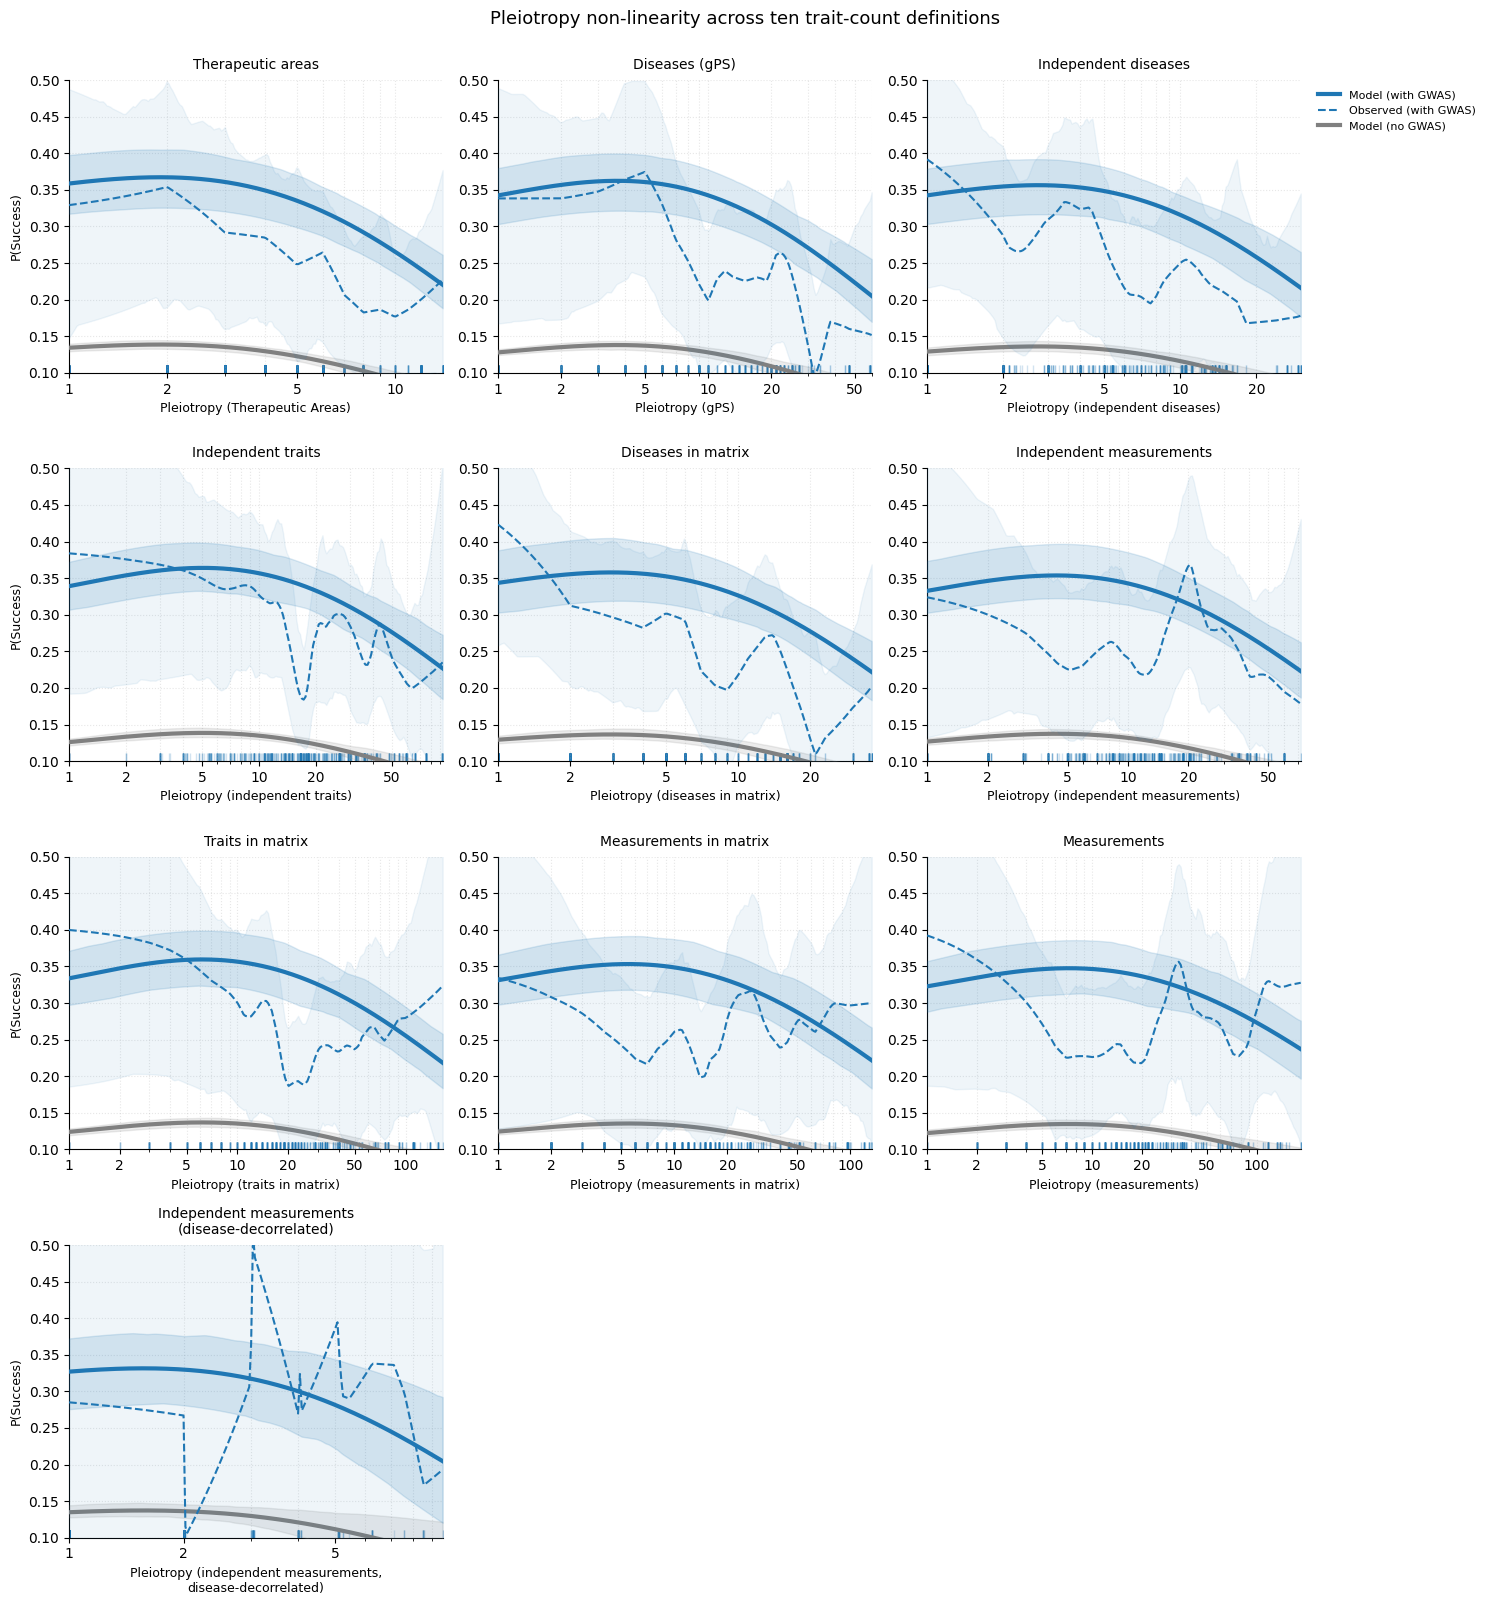

saved eit_step4_ninepanel-r1.pdf


In [6]:
def plot_panel(ax, curve, xlabel, title, show_legend=False, show_ylabel=False):
    x_grid = curve["x_grid"]
    ax.plot(x_grid, curve["model_gs1"], color="#1f77b4", lw=3, label="Model (with GWAS)", zorder=10)
    ax.fill_between(x_grid, curve["ci_gs1"][0], curve["ci_gs1"][1], color="#1f77b4", alpha=0.15, zorder=9)

    ax.plot(x_grid, curve["lowess_gs1"], color="#1f77b4", lw=1.5, ls="--", label="Observed (with GWAS)", zorder=8)
    ax.fill_between(x_grid, curve["lowess_ci_gs1"][0], curve["lowess_ci_gs1"][1], color="#1f77b4", alpha=0.07, zorder=7)

    ax.plot(x_grid, curve["model_gs0"], color="gray", lw=3, label="Model (no GWAS)", zorder=6)
    ax.fill_between(x_grid, curve["ci_gs0"][0], curve["ci_gs0"][1], color="gray", alpha=0.15, zorder=5)

    ax.plot(curve["rug"], np.full(len(curve["rug"]), 0.105), "|", color="#1f77b4", alpha=0.2, zorder=1)

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())
    candidate_ticks = [1, 2, 5, 10, 20, 50, 100, 200]
    ax.set_xticks([t for t in candidate_ticks if curve["x_min"] <= t <= curve["x_max"]])
    ax.set_xlim(curve["x_min"], curve["x_max"])
    ax.set_ylim(0.1, 0.5)

    ax.set_xlabel(xlabel, fontsize=9)
    if show_ylabel:
        ax.set_ylabel("P(Success)", fontsize=9)
    ax.set_title(title, fontsize=10, pad=8)
    ax.grid(True, which="both", ls=":", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    if show_legend:
        ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)


fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for i, spec in enumerate(METRIC_SPECS):
    ax = axes.flat[i]
    plot_panel(
        ax,
        curves[spec["label"]],
        spec["xlabel"],
        spec["label"],
        show_legend=(i == 2),
        show_ylabel=(i % 3 == 0),
    )
for j in range(len(METRIC_SPECS), axes.size):
    axes.flat[j].axis("off")

fig.suptitle("Pleiotropy non-linearity across ten trait-count definitions", fontsize=13, y=1.0)
plt.tight_layout()
fig.savefig("eit_step4_ninepanel-r1.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("saved eit_step4_ninepanel-r1.pdf")

## Reading

Panels 1-2 are the main-text figure. Panels 3, 5 (independent/matrix-restricted diseases) keep the
same rise-then-fall shape and a visibly separated no-GWAS baseline. Panels 4, 6-9 (traits and
measurement-based counts) show the same rise but a much flatter or absent fall — consistent with the
`limbs`/`p_quadratic` tables in `02_drug_targets.ipynb`, where the measurement axis does not carry a
significant declining limb. Panel 10 (measurements with disease-correlated traits removed) shows no
decline at all — the low/high ratio is *below* 1 (0.65, P = 0.33 Wald / 0.48 permutation), the opposite
of the paper's claim, on a much smaller gene set (26% of genes have any surviving trait). This
reinforces rather than overturns the measurement-axis conclusion: removing the disease-correlated
measurement traits does not reveal a hidden ceiling effect. No new statistic is computed here beyond
what `02_drug_targets.ipynb` exports; this figure is its visual companion.